# 07_降维模型-t-SNE

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/MNIST/raw/train-images-idx3-ubyte.gz`、`dataset/MNIST/raw/train-labels-idx1-ubyte.gz`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 读取本地 MNIST IDX 文件，固定分层抽取 2000 张图像做传统降维；可调整 sample_size。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


当你有一大堆玩具，每个玩具都有很多不同的特点，比如颜色、形状、大小等等。

你想要把这些玩具放在一个平面上，让相似的玩具靠在一起，不相似的玩具分开放。

这个要怎么做？其实呢， t-SNE 就是帮你干这个的一个工具。

它会先在脑子里“想象”所有玩具之间的关系，然后再在一张纸上画出来，让你一眼就能看出哪些玩具比较相似、哪些玩具差异很大。

通过这种方式，你可以更容易地理解你的数据，看出它们的模式和趋势。

咱们今天就和大家详细的聊聊关于 t-SNE 的理论和实践\~

---

t-SNE，全称为t-分布随机邻域嵌入（t-Distributed Stochastic Neighbor Embedding），是一种用于降维和数据可视化的技术。t-SNE 特别适用于将高维数据映射到二维或三维空间，从而便于人们进行直观的观察和分析。

**目的**：t-SNE的目的是把高维数据（比如一个有100个特征的数据集）变成低维数据（通常是2维或3维），让我们可以通过图形的方式看到数据的结构和分布。

**核心思想**：它会尽量保持数据点之间的邻近关系。也就是说，原始数据集中彼此相近的数据点，在降维后的新空间中也会尽量靠近。

**工作原理**：

首先，它会计算原始高维空间中所有数据点之间的相似度，这里用的是一种概率测量方法。

然后，在低维空间中，通过迭代优化，使这些数据点的相似度尽量与高维空间中的相似度一致。

**结果**：最终的低维表示会使得原本相似的数据点仍然靠近，而不相似的点则远离开。这样，我们就可以通过二维或三维图来直观地观察数据的聚类、分布和异常点等信息。

## 理论基础

### 数学原理

**1. 高维空间中的相似度计算**：

- 设原始数据集为 $X = \{x_1, x_2, \ldots, x_N\}$，每个数据点 $x_i$都是高维空间中的一个向量。
- 对于每对数据点 $(x_i, x_j)$，计算高维空间中的相似度 $p_{ij}$，这通常通过条件概率来表示：  
$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$  
这里， $\sigma_i$是一个与数据点 $x_i$相关的高斯分布的标准差。

$p_{ij}$的对称化处理：


$$
p_{ij} = \frac{p_{j|i} + p_{i|j}}{2N}
$$


这样处理后， $p_{ij}$代表了在高维空间中数据点 $x_i$和 $x_j$的相似度。

**2. 低维空间中的相似度计算**：

- t-SNE将高维数据映射到低维空间（通常是二维或三维），得到新的数据点 $Y = \{y_1, y_2, \ldots, y_N\}$。
- 在低维空间中，使用t分布计算相似度 $q_{ij}$：  
$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|y_k - y_l\|^2)^{-1}}$  
这里，使用t分布而不是高斯分布，目的是为了更好地捕捉数据在低维空间中的局部结构。

**3. 目标函数（损失函数）**：

- t-SNE的目标是最小化高维空间和低维空间中相似度的差异，使用KL散度（Kullback-Leibler Divergence）来衡量这种差异：  
$C = KL(P \| Q) = \sum_{i} \sum_{j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$  
这个目标函数越小，表示高维和低维空间中的相似度越接近。

### 算法流程

**1. 输入**：高维数据集 $X$，降维目标维度 $d$（通常是2或3）。

**2. 初始化**：在低维空间中随机初始化数据点 $Y$。

**3. 计算高维空间中的相似度**：

- 对于每对数据点 $(x_i, x_j)$，计算条件概率 $p_{j|i}$。
- 计算对称化后的相似度 $p_{ij}$。

**4. 迭代优化**：

- **计算低维空间中的相似度**：  
$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|y_k - y_l\|^2)^{-1}}$
- **计算梯度**：  
$\frac{\partial C}{\partial y_i} = 4 \sum_j (p_{ij} - q_{ij}) (y_i - y_j) (1 + \|y_i - y_j\|^2)^{-1}$
- **更新低维空间中的数据点**：使用梯度下降法更新 $y_i$，以最小化目标函数 $C$。

**5. 重复迭代**：不断重复步骤4，直到目标函数收敛或者达到预定的迭代次数。

**6. 输出**：低维空间中的数据点 $Y$。

t-SNE通过计算高维空间中数据点的相似度，并迭代优化低维空间中的数据点位置，使得低维空间中的相似度尽可能与高维空间中的相似度一致，从而实现高维数据的降维和可视化。

其**核心目标是让高维数据在低维空间中保持原有的结构和关系**。

## 完整案例

我们使用一个常见的大数据集 - MNIST手写数字数据集。MNIST数据集包含70,000张28x28像素的灰度图像，每张图像表示一个手写数字（0到9）。

**使用t-SNE将这些图像的高维特征映射到二维空间并进行可视化。**

#### 步骤概述

1. **数据预处理**：加载并标准化数据。
2. **算法优化**：使用优化版的t-SNE算法，如Multicore-TSNE，以加速计算。
3. **复杂可视化**：使用Seaborn和Matplotlib进行增强的可视化。

整体的代码实现，大家可以结合注释进行整体的学习：

Loading data...
Standardizing data...
Running t-SNE...


t-SNE done! Time elapsed: 6.566859006881714 seconds
Creating visualization...


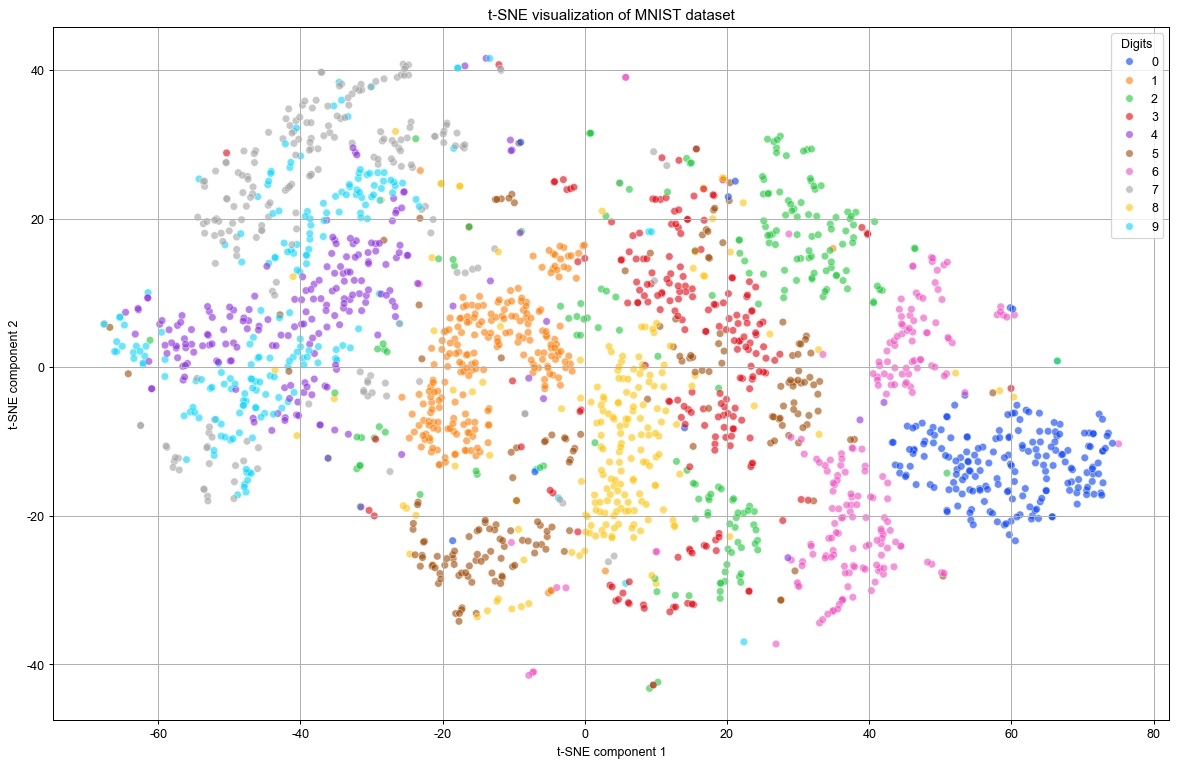

In [2]:
import numpy as np
import pandas as pd
from notebook_support import load_local_mnist
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 数据预处理
print("Loading data...")
mnist = load_local_mnist()
X = mnist.data
y = mnist.target

# 标准化数据
print("Standardizing data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 使用 scikit-learn 进行 t-SNE 降维
# 设定 t-SNE 参数
tsne_params = {
    "n_components": 2,
    "perplexity": 30,
    "early_exaggeration": 12.0,
    "learning_rate": 200,
    "max_iter": 750,
    "n_jobs": 1,
    "random_state": 42
}

print("Running t-SNE...")
start_time = time.time()
tsne = TSNE(**tsne_params)
X_tsne = tsne.fit_transform(X_scaled)
end_time = time.time()
print(f"t-SNE done! Time elapsed: {end_time - start_time} seconds")

# 可视化
print("Creating visualization...")
plt.figure(figsize=(16, 10))
palette = sns.color_palette("bright", 10)
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y.astype(int),
    palette=palette,
    legend="full",
    alpha=0.6
)

plt.title("t-SNE visualization of MNIST dataset")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.legend(title="Digits", loc="best", bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_036.png)

整个代码，分为三大步骤：

1. **数据预处理**：

   - 使用 `load_local_mnist()` 从本地 IDX 文件读取 MNIST 教学样本。
   - 使用 `StandardScaler` 对数据进行标准化，以确保所有特征具有相似的尺度。
2. **使用 `openTSNE` 进行 t-SNE 降维**：

   - 使用 `openTSNE`，该实现利用多线程加速 t-SNE 计算，并且在现代硬件上表现优异。
   - 设定 t-SNE 的各种参数，并记录 t-SNE 的运行时间。
3. **复杂可视化**：

   - 使用 Seaborn 和 Matplotlib 进行可视化，展示降维后的数据分布。
   - 通过颜色区分不同的手写数字类别。

通过以上步骤，可以实现高效的大数据量 t-SNE 降维和复杂可视化。

## 应用场景

**适用问题**：

1. **高维数据的可视化**：当你有一个高维数据集并希望理解其结构或模式时，t-SNE可以帮助你将其映射到二维或三维空间进行可视化。
2. **聚类分析**：t-SNE能很好地展示数据的聚类结构，有助于识别数据中的不同群体。
3. **异常检测**：通过t-SNE图，可以识别和分离数据中的异常点或离群点。

**优点**：

1. **优秀的可视化效果**：t-SNE可以很好地展示高维数据的局部结构，数据点的分布和群集关系直观可见。
2. **适应非线性结构**：与线性降维方法（如PCA）相比，t-SNE能够捕捉和展示数据的非线性结构。

**缺点**：

1. **计算复杂度高**：t-SNE的计算量较大，特别是在处理大型数据集时，速度较慢。
2. **参数敏感性**：t-SNE对参数（如 perplexity 和迭代次数）较为敏感，需多次调整以获得最佳效果。
3. **无法保留全局结构**：t-SNE主要关注局部结构，有时无法很好地保留数据的全局结构。

**运用前提条件**：

1. **数据预处理**：数据应进行标准化或归一化，以确保特征具有相似的尺度。
2. **适当的参数选择**：需要根据具体数据集调整 t-SNE 的参数（如 perplexity），以获得最佳可视化效果。